In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [2]:
from sklearn.datasets import fetch_california_housing

rohdaten = fetch_california_housing()
df = pd.DataFrame(rohdaten.data, columns=rohdaten.feature_names)
df['Preis'] = rohdaten.target
df.head(10)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Preis
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Preis       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


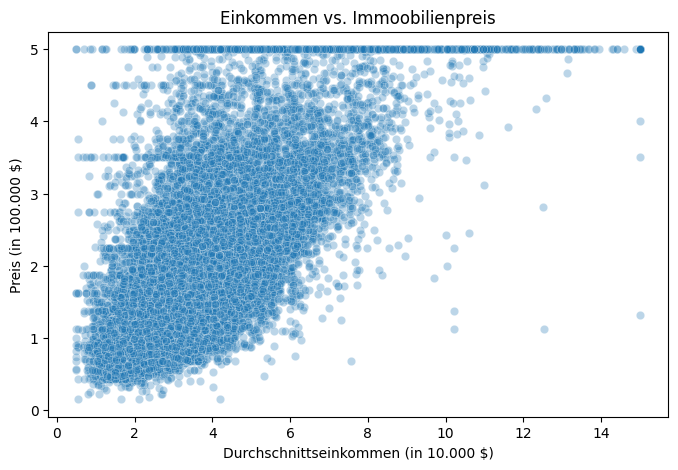

In [6]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data = df,x='MedInc', y='Preis',alpha=0.3)
plt.title('Einkommen vs. Immoobilienpreis')
plt.xlabel("Durchschnittseinkommen (in 10.000 $)")
plt.ylabel("Preis (in 100.000 $)")
plt.show()

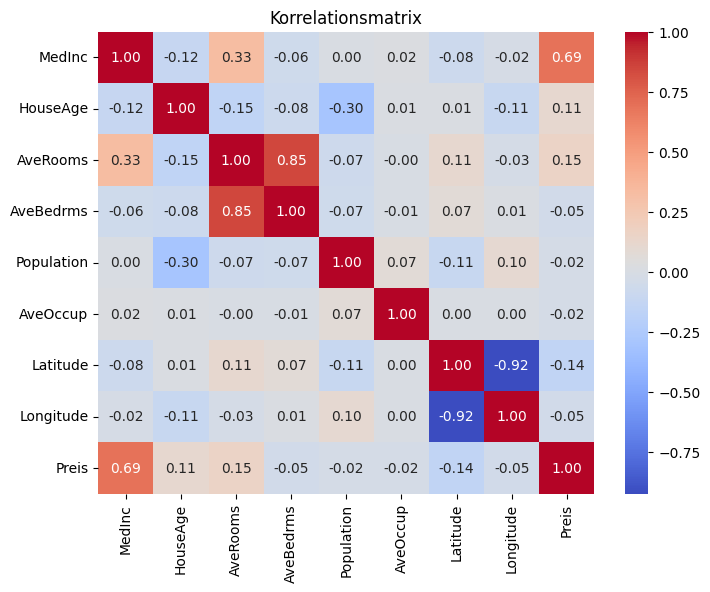

In [8]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(),annot=True, cmap='coolwarm',fmt='.2f')
plt.title('Korrelationsmatrix')
plt.show()

In [10]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['Preis'])
y = df['Preis']
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=42)
print(f"Trainingsdaten: {X_train.shape[0]} Zeilen")
print(f"Testdaten: {X_test.shape[0]} Zeilen")

Trainingsdaten: 16512 Zeilen
Testdaten: 4128 Zeilen


In [13]:
from xgboost import XGBRegressor

modell = XGBRegressor(n_estimators=100, random_state=42)
modell.fit(X_train, y_train)

print("Modell erfolgreich trainiert! ✅")

Modell erfolgreich trainiert! ✅


In [15]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = modell.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f} (in 100.000$)")
print(f"R²: {r2:.2f}")

MAE: 0.31 (in 100.000$)
R²: 0.83


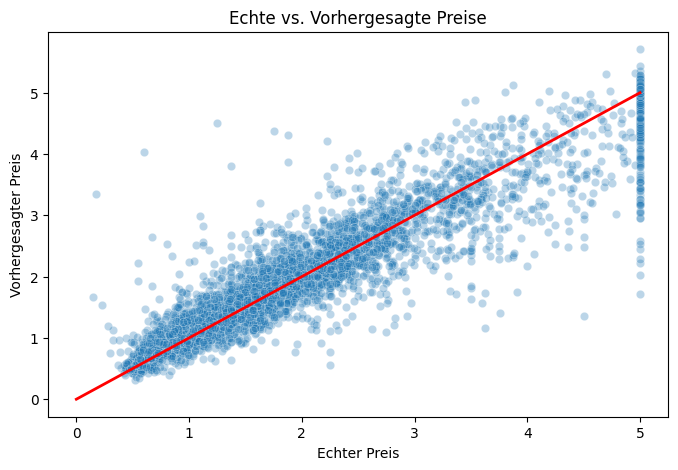

In [17]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.3)
plt.plot([0, 5], [0, 5], color='red', linewidth=2)
plt.xlabel('Echter Preis')
plt.ylabel('Vorhergesagter Preis')
plt.title('Echte vs. Vorhergesagte Preise')
plt.show()

In [19]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"Beste Parameter: {grid_search.best_params_}")
print(f"Bester R² Score: {grid_search.best_score_:.2f}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Beste Parameter: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.8}
Bester R² Score: 0.84


In [23]:
bestes_modell = grid_search.best_estimator_

y_pred_best = bestes_modell.predict(X_test)

mae_best = mean_absolute_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)

print(f"Vorher → MAE: 0.31 | R²: 0.83")
print(f"Nachher → MAE: {mae_best:.2f} | R²: {r2_best:.2f}")

Vorher → MAE: 0.31 | R²: 0.83
Nachher → MAE: 0.29 | R²: 0.85


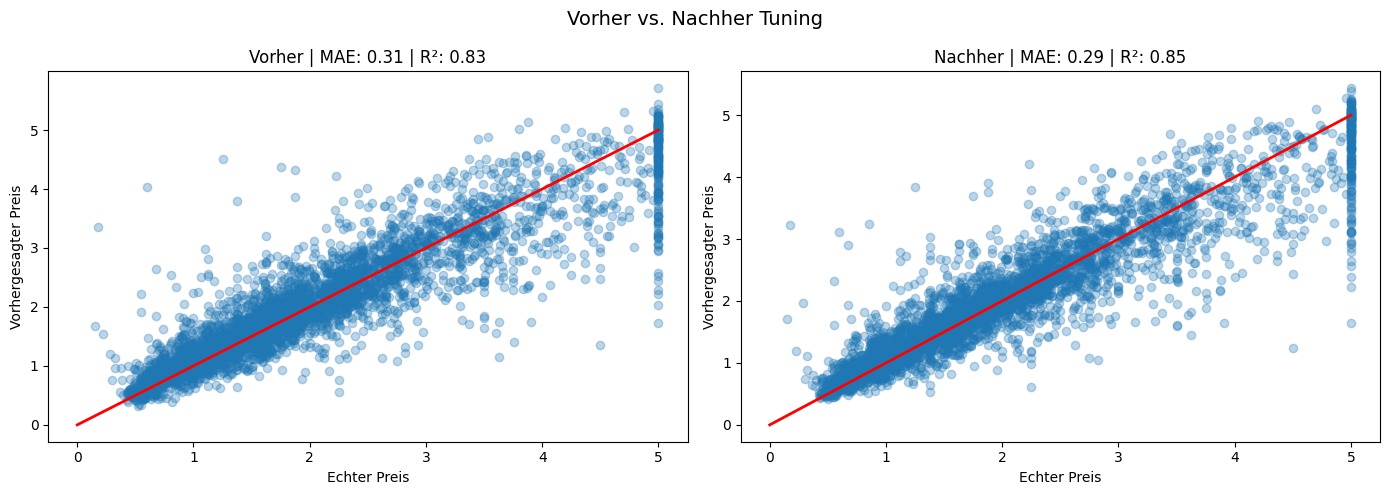

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Vorher
axes[0].scatter(y_test, y_pred, alpha=0.3)
axes[0].plot([0, 5], [0, 5], color='red', linewidth=2)
axes[0].set_xlabel('Echter Preis')
axes[0].set_ylabel('Vorhergesagter Preis')
axes[0].set_title(f'Vorher | MAE: 0.31 | R²: 0.83')

# Nachher
axes[1].scatter(y_test, y_pred_best, alpha=0.3)
axes[1].plot([0, 5], [0, 5], color='red', linewidth=2)
axes[1].set_xlabel('Echter Preis')
axes[1].set_ylabel('Vorhergesagter Preis')
axes[1].set_title(f'Nachher | MAE: 0.29 | R²: 0.85')

plt.suptitle('Vorher vs. Nachher Tuning', fontsize=14)
plt.tight_layout()
plt.show()

In [26]:
import joblib

joblib.dump(modell, 'modell.pkl')
print("Modell gespeichert! ✅")

Modell gespeichert! ✅
